# Лабораторна робота №3
## Часово-частотний аналіз звукових сигналів
Мета: освоїти методи спектрального аналізу аудіо.

### Основні завдання
• Завантажити аудіосигнал.  
• Побудувати його часову форму.  
• Обчислити FFT.  
• Побудувати амплітудний спектр.  
• Виконати STFT.  
• Побудувати spectrogram.  
• Побудувати Mel-spectrogram.  
• Порівняти представлення одного сигналу у часовій та частотній областях.  
### Дослідницька складова
Дослідити вплив параметрів STFT - n_fft, hop_length, window — на роздільну здатність спектрограми.

### Дослідницькі питання
• Що показує FFT і чого він не показує порівняно зі спектрограмою?  
• Як розмір вікна n_fft впливає на роздільну здатність по частоті та по часу?  
• Що змінює hop_length?  
• Як вибір функції вікна (window) впливає на спектральні витоки?  
• Чим Mel-spectrogram відрізняється від звичайної спектрограми і де її доцільно застосовувати?  
#### Результат: *графіки, таблиці параметрів та обґрунтований висновок*.  
---

### Завантажуємо аудіосигнал
Читаємо власний WAV-файл через `librosa.load`.

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import scipy.signal

file_name = "audio.wav"

# sr=None зберігає оригінальну частоту дискретизації файлу
y, sr = librosa.load(file_name, sr=None, mono=True)
duration = len(y) / sr
t = np.arange(len(y)) / sr

print("Інформація про аудіосигнал:\n")
print(f"Файл: {file_name}")
print(f"Тривалість: {duration:.2f} с")
print(f"Частота дискретизації: {sr} Гц")
print(f"Кількість відліків: {len(y)}")

Інформація про аудіосигнал:

Файл: audio.wav
Тривалість: 4.25 с
Частота дискретизації: 48000 Гц
Кількість відліків: 203776


### Часова форма (waveform)
Амплітуда сигналу як функція часу. З неї видно гучність і загальну структуру, але не видно, які саме частоти звучать.

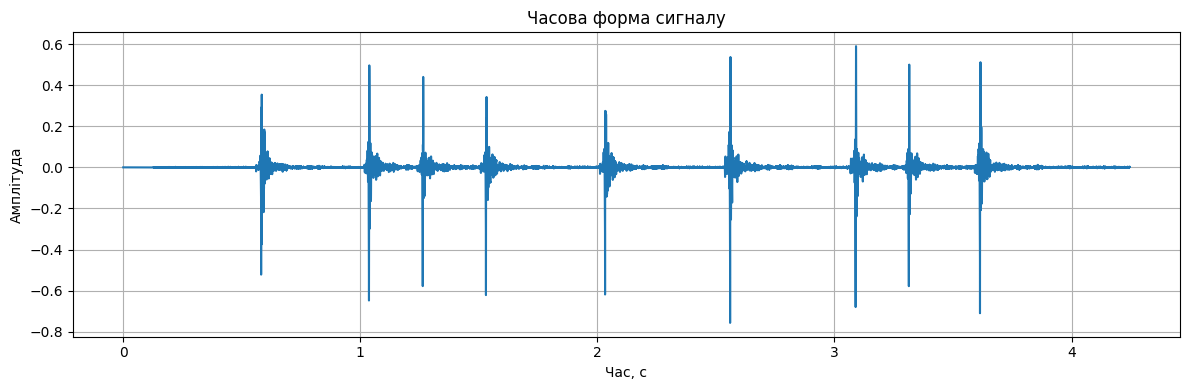

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(t, y)
plt.xlabel("Час, с")
plt.ylabel("Амплітуда")
plt.title("Часова форма сигналу")
plt.grid(True)
plt.tight_layout()
plt.show()

### FFT та амплітудний спектр
FFT показує, які частоти присутні в сигналі **в цілому**, але не показує, коли саме вони звучали.

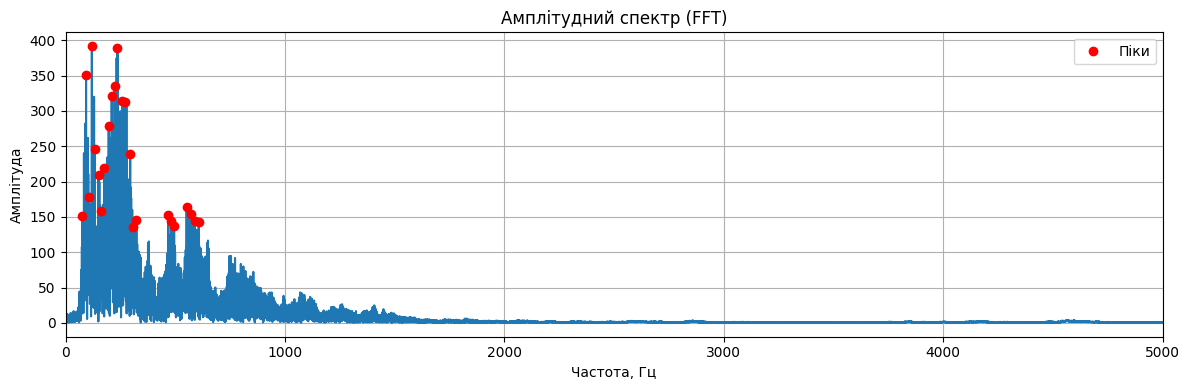

Знайдені піки спектра:
  75.8 Гц  (амплітуда 151.3)
  93.0 Гц  (амплітуда 350.2)
  106.2 Гц  (амплітуда 178.7)
  119.4 Гц  (амплітуда 391.6)
  133.6 Гц  (амплітуда 246.5)
  149.8 Гц  (амплітуда 208.7)
  163.2 Гц  (амплітуда 157.7)
  176.4 Гц  (амплітуда 219.6)
  196.2 Гц  (амплітуда 278.0)
  209.9 Гц  (амплітуда 321.5)
  223.1 Гц  (амплітуда 335.5)
  236.3 Гц  (амплітуда 388.6)
  259.1 Гц  (амплітуда 314.7)
  272.3 Гц  (амплітуда 312.4)
  294.2 Гц  (амплітуда 238.9)
  306.5 Гц  (амплітуда 136.2)
  322.5 Гц  (амплітуда 145.3)
  468.0 Гц  (амплітуда 152.8)
  481.2 Гц  (амплітуда 144.0)
  494.4 Гц  (амплітуда 137.3)
  551.4 Гц  (амплітуда 163.4)
  573.6 Гц  (амплітуда 154.6)
  587.5 Гц  (амплітуда 143.9)
  606.5 Гц  (амплітуда 142.5)


In [21]:
# FFT для речових сигналів (rfft повертає лише додатні частоти)
N = len(y)
fft_values = np.fft.rfft(y)
fft_freqs = np.fft.rfftfreq(N, d=1 / sr)
fft_amplitude = np.abs(fft_values)

# Пошук основних піків спектра
peaks, _ = scipy.signal.find_peaks(fft_amplitude, height=fft_amplitude.max() * 0.3, distance=50)

plt.figure(figsize=(12, 4))
plt.plot(fft_freqs, fft_amplitude)
plt.plot(fft_freqs[peaks], fft_amplitude[peaks], "ro", label="Піки")
plt.xlim(0, min(5000, sr / 2))
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.title("Амплітудний спектр (FFT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Знайдені піки спектра:")
for p in peaks:
    print(f"  {fft_freqs[p]:.1f} Гц  (амплітуда {fft_amplitude[p]:.1f})")

### STFT та spectrogram
Рахуємо FFT не для всього сигналу, а для невеликих вікон, що ковзають по часу.
Ключові параметри: **n_fft** — розмір вікна, **hop_length** — крок зсуву вікна, **window** — функція вікна.

Форма матриці STFT (частоти x часові кадри): (1025, 399)


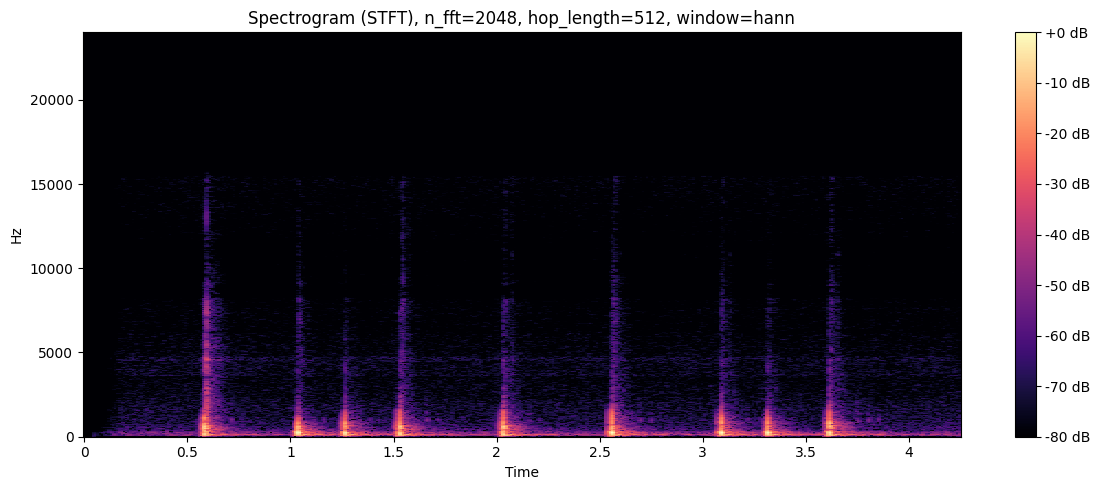

In [22]:
n_fft = 2048
hop_length = 512
window = "hann"

# STFT: комплексна матриця (частоти x часові кадри)
stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window=window)
stft_magnitude = np.abs(stft)
stft_db = librosa.amplitude_to_db(stft_magnitude, ref=np.max)

print(f"Форма матриці STFT (частоти x часові кадри): {stft.shape}")

plt.figure(figsize=(12, 5))
img = librosa.display.specshow(stft_db, sr=sr, hop_length=hop_length,
                               x_axis="time", y_axis="hz", cmap="magma")
plt.colorbar(img, format="%+2.0f dB")
plt.title(f"Spectrogram (STFT), n_fft={n_fft}, hop_length={hop_length}, window={window}")
plt.tight_layout()
plt.show()

### Mel-spectrogram
Мел-шкала наближена до людського слухового сприйняття: низькі частоти розрізняються детальніше, високі — грубіше.

Форма мел-спектрограми (мел-смуги x часові кадри): (128, 399)


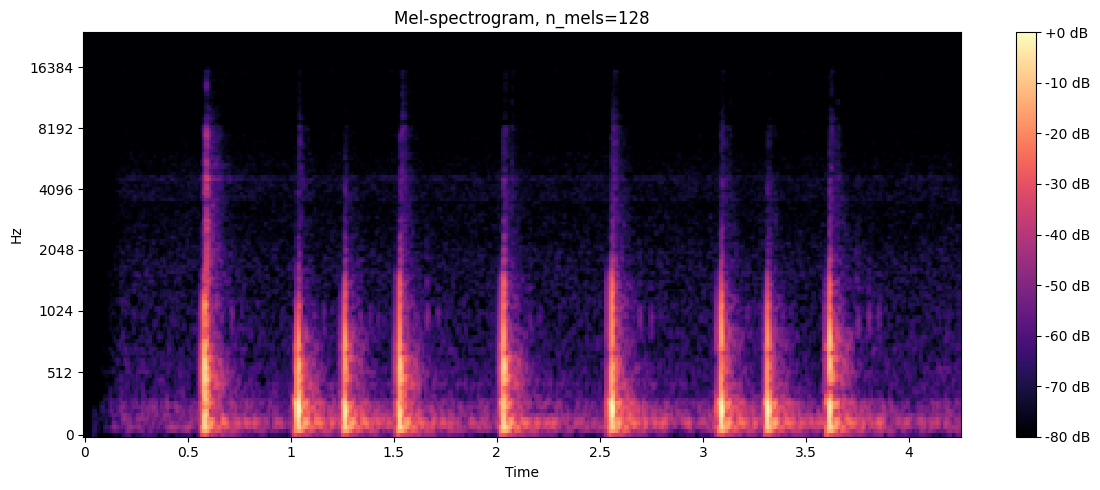

In [23]:
n_mels = 128

mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
                                     window=window, n_mels=n_mels)
mel_db = librosa.power_to_db(mel, ref=np.max)

print(f"Форма мел-спектрограми (мел-смуги x часові кадри): {mel.shape}")

plt.figure(figsize=(12, 5))
img = librosa.display.specshow(mel_db, sr=sr, hop_length=hop_length,
                               x_axis="time", y_axis="mel", cmap="magma")
plt.colorbar(img, format="%+2.0f dB")
plt.title(f"Mel-spectrogram, n_mels={n_mels}")
plt.tight_layout()
plt.show()

### Порівняння часової та частотної областей
Усі чотири представлення одного й того самого сигналу.

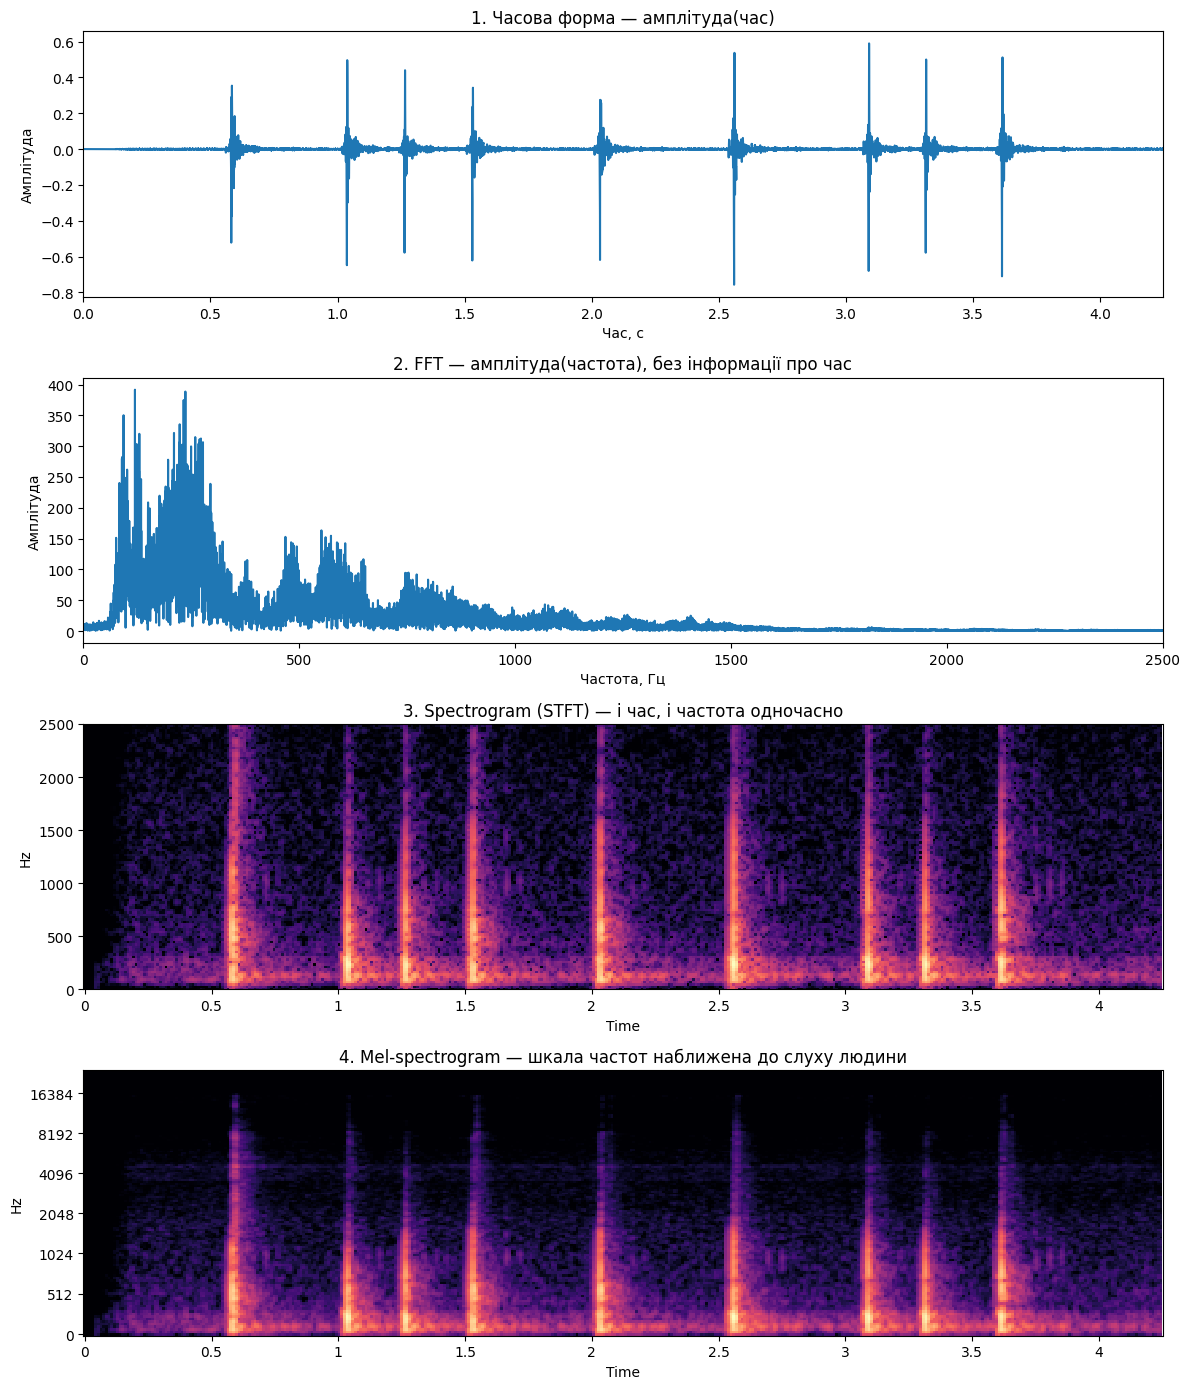

In [24]:
plt.figure(figsize=(12, 14))

plt.subplot(4, 1, 1)
plt.plot(t, y)
plt.xlim(0, duration)
plt.xlabel("Час, с")
plt.ylabel("Амплітуда")
plt.title("1. Часова форма — амплітуда(час)")

plt.subplot(4, 1, 2)
plt.plot(fft_freqs, fft_amplitude)
plt.xlim(0, min(2500, sr / 2))
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.title("2. FFT — амплітуда(частота), без інформації про час")

ax3 = plt.subplot(4, 1, 3)
librosa.display.specshow(stft_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz", cmap="magma", ax=ax3)
ax3.set_ylim(0, min(2500, sr / 2))
ax3.set_title("3. Spectrogram (STFT) — і час, і частота одночасно")

ax4 = plt.subplot(4, 1, 4)
librosa.display.specshow(mel_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel", cmap="magma", ax=ax4)
ax4.set_title("4. Mel-spectrogram — шкала частот наближена до слуху людини")

plt.tight_layout()
plt.show()

## Дослідження параметрів STFT
Досліджуємо, як **n_fft**, **hop_length** та **window** впливають на роздільну здатність спектрограми.  
Теоретично: роздільність по частоті Δf = sr / n_fft, довжина вікна у часі = n_fft / sr, крок по часу = hop_length / sr.

### 1. Вплив n_fft (hop_length = 512, window = hann)

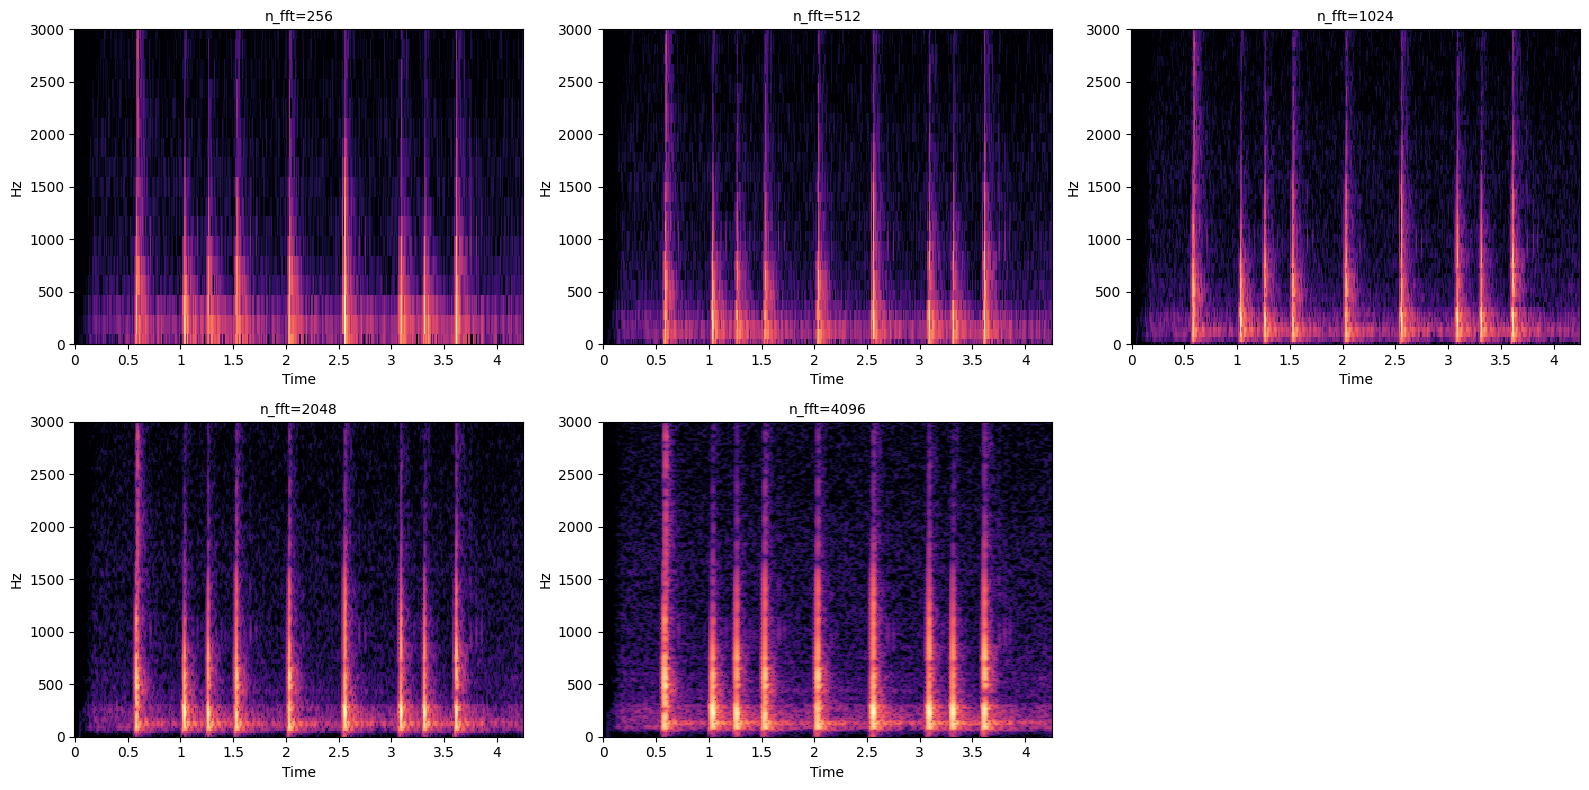

n_fft   Δf, Гц      Вікно, мс     К-сть частот   К-сть кадрів
-------------------------------------------------------------
256     187.50      5.3           129            399         
512     93.75       10.7          257            399         
1024    46.88       21.3          513            399         
2048    23.44       42.7          1025           399         
4096    11.72       85.3          2049           399         


In [25]:
def plot_spectrogram(ax, y, sr, n_fft, hop_length, window, title, fmax=None):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window=window)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                             x_axis="time", y_axis="hz", cmap="magma", ax=ax)
    if fmax is not None:
        ax.set_ylim(0, fmax)
    ax.set_title(title, fontsize=10)
    return S.shape


fmax_plot = min(3000, sr / 2)

n_fft_values = [256, 512, 1024, 2048, 4096]
fixed_hop = 512

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
rows = []

for ax, nf in zip(axes, n_fft_values):
    shape = plot_spectrogram(ax, y, sr, nf, fixed_hop, "hann", f"n_fft={nf}", fmax=fmax_plot)
    rows.append([nf, sr / nf, nf / sr * 1000, shape[0], shape[1]])
axes[-1].axis("off")

plt.tight_layout()
plt.show()

print(f"{'n_fft':<8}{'Δf, Гц':<12}{'Вікно, мс':<14}{'К-сть частот':<15}{'К-сть кадрів':<12}")
print("-" * 61)
for nf, df, win_ms, n_freqs, n_frames in rows:
    print(f"{nf:<8}{df:<12.2f}{win_ms:<14.1f}{n_freqs:<15}{n_frames:<12}")

### 2. Вплив hop_length (n_fft = 2048, window = hann)

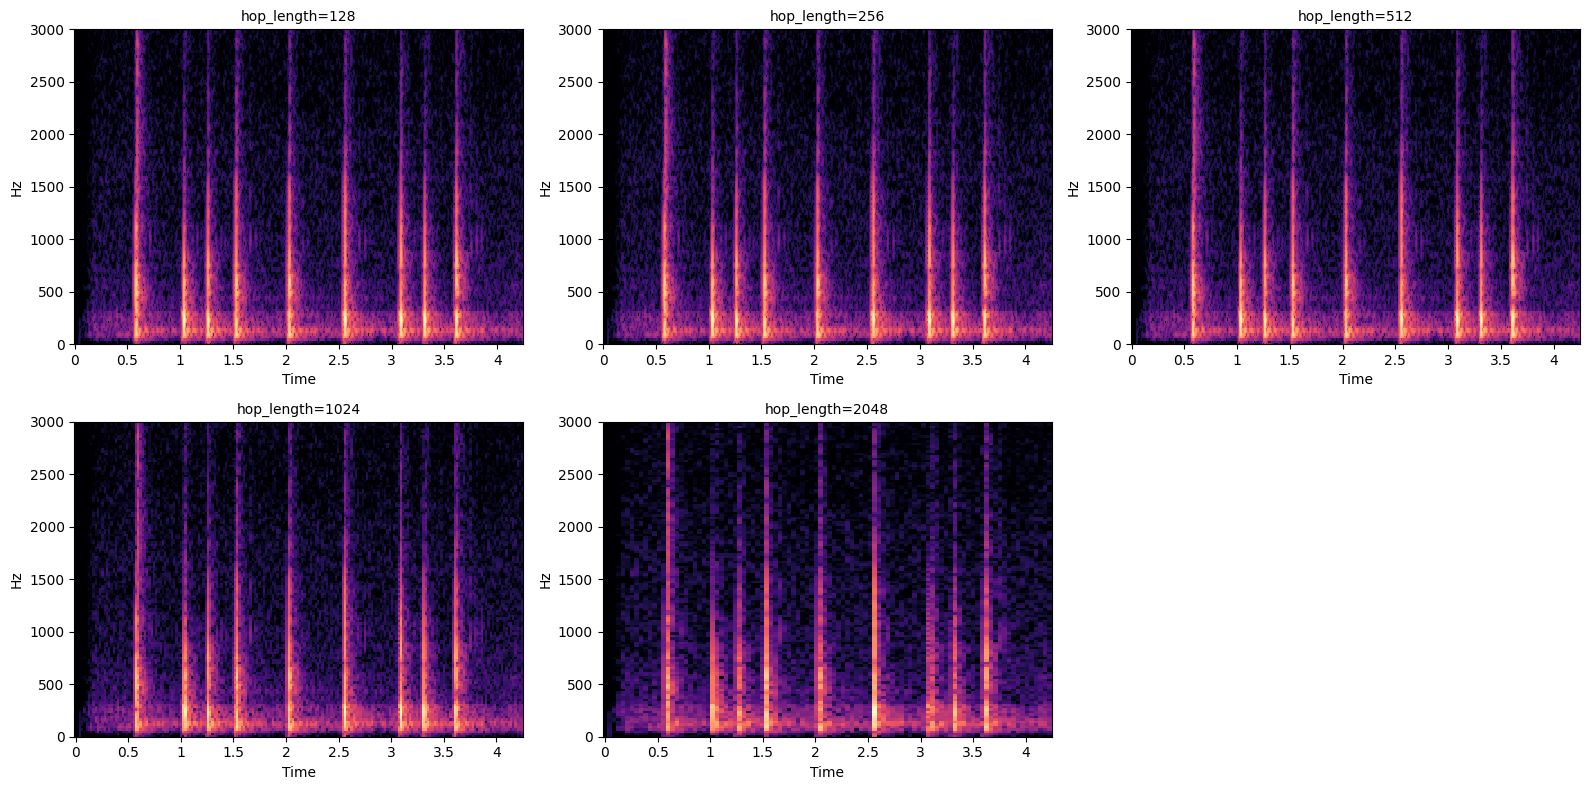

hop_length  Крок, мс    Перекриття, %   К-сть кадрів
----------------------------------------------------
128         2.7         93.8            1593        
256         5.3         87.5            797         
512         10.7        75.0            399         
1024        21.3        50.0            200         
2048        42.7        0.0             100         


In [26]:
hop_values = [128, 256, 512, 1024, 2048]
fixed_n_fft = 2048

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
rows = []

for ax, hl in zip(axes, hop_values):
    shape = plot_spectrogram(ax, y, sr, fixed_n_fft, hl, "hann", f"hop_length={hl}", fmax=fmax_plot)
    rows.append([hl, hl / sr * 1000, 100 * (1 - hl / fixed_n_fft), shape[1]])
axes[-1].axis("off")

plt.tight_layout()
plt.show()

print(f"{'hop_length':<12}{'Крок, мс':<12}{'Перекриття, %':<16}{'К-сть кадрів':<12}")
print("-" * 52)
for hl, step_ms, overlap, n_frames in rows:
    print(f"{hl:<12}{step_ms:<12.1f}{overlap:<16.1f}{n_frames:<12}")

### 3. Вплив функції вікна window (n_fft = 2048, hop_length = 512)
Порівнюємо вікна Hann, Hamming, Blackman та прямокутне (boxcar). Спочатку — спектрограми, потім спектр одного кадра в дБ, де краще видно спектральні витоки.

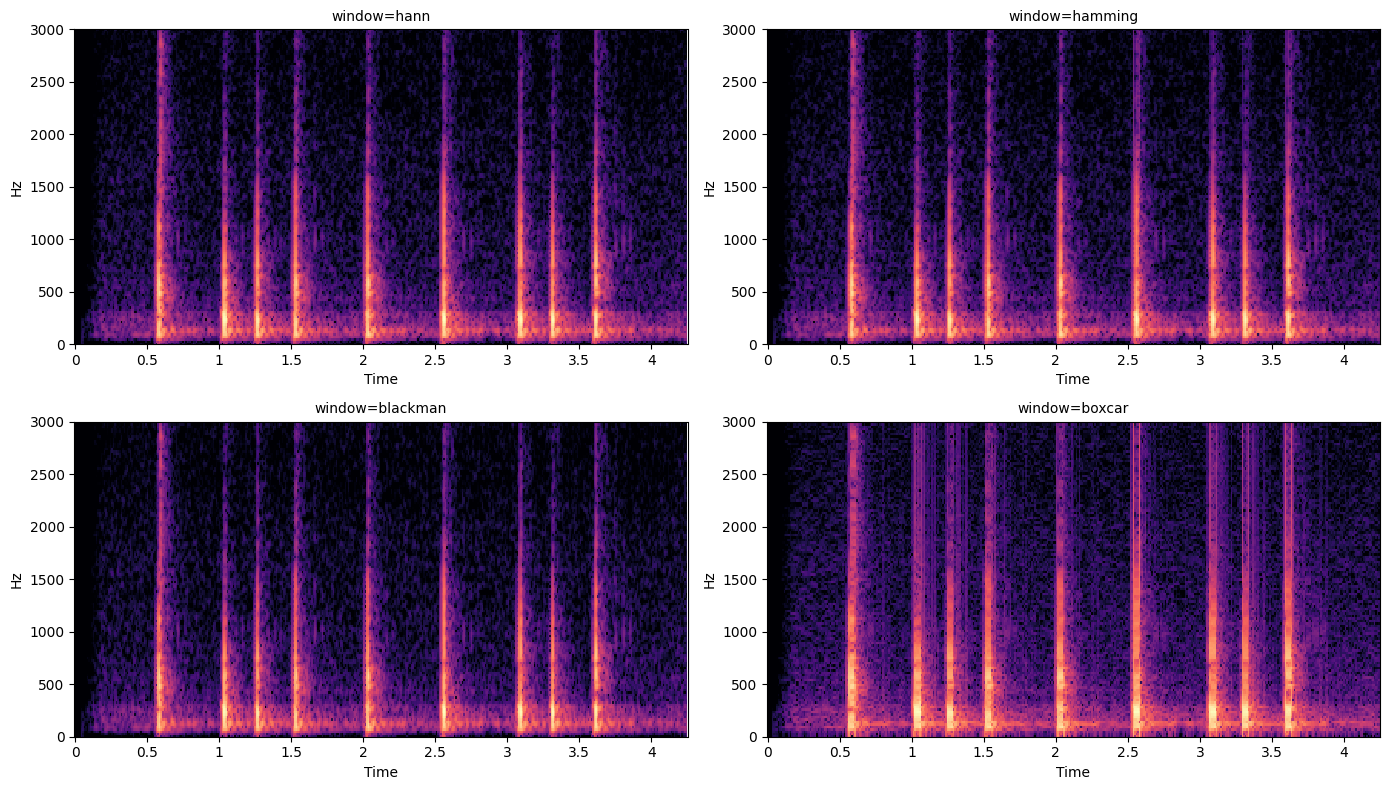

In [27]:
window_types = ["hann", "hamming", "blackman", "boxcar"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, w in zip(axes, window_types):
    plot_spectrogram(ax, y, sr, 2048, 512, w, f"window={w}", fmax=fmax_plot)

plt.tight_layout()
plt.show()

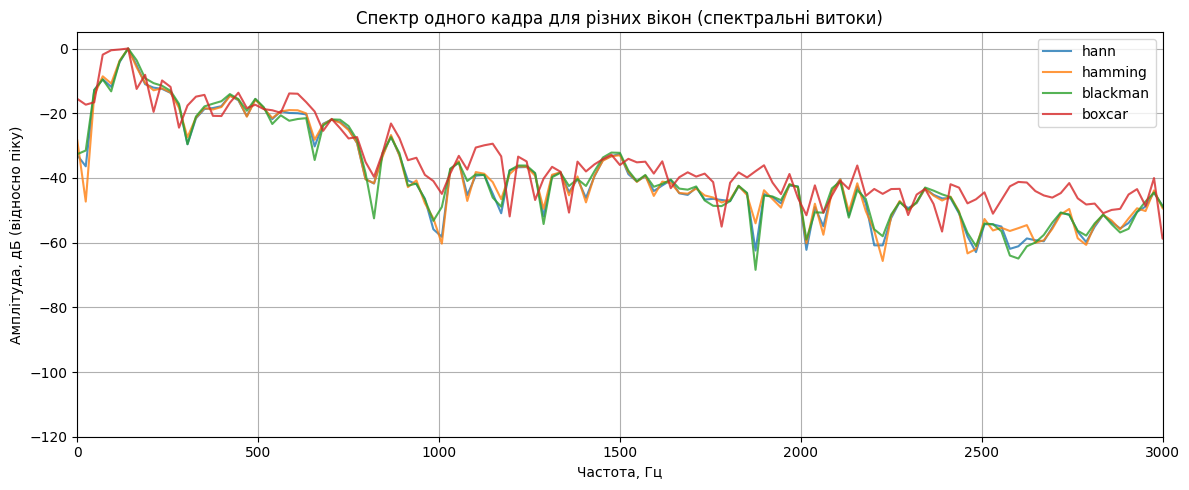

In [28]:
# Спектр одного кадра (з середини сигналу) для різних вікон
n_fft_w = 2048
center = len(y) // 2
frame = y[center - n_fft_w // 2: center + n_fft_w // 2]
freqs_w = np.fft.rfftfreq(n_fft_w, d=1 / sr)

plt.figure(figsize=(12, 5))
for w in window_types:
    win = scipy.signal.get_window(w, n_fft_w)
    spectrum = np.abs(np.fft.rfft(frame * win))
    spectrum_db = 20 * np.log10(spectrum / spectrum.max() + 1e-10)
    plt.plot(freqs_w, spectrum_db, label=w, alpha=0.8)

plt.xlim(0, fmax_plot)
plt.ylim(-120, 5)
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда, дБ (відносно піку)")
plt.title("Спектр одного кадра для різних вікон (спектральні витоки)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Висновки
- **Що показує FFT і чого він не показує порівняно зі спектрограмою?**  
FFT показує, які частоти присутні в сигналі загалом (піки на графіку відповідають нотам/тонам), але повністю втрачає інформацію про час: за амплітудним спектром неможливо сказати, коли саме звучала кожна частота. Часова форма, навпаки, показує гучність у часі, але не показує частотний склад. Спектрограма (STFT) об'єднує обидва виміри: видно і що звучить, і коли — зокрема зміну частоти в часі (чирп виглядає як похила лінія).

- **Як розмір вікна n_fft впливає на роздільну здатність по частоті та по часу?**  
Це компроміс (принцип невизначеності): роздільність по частоті Δf = sr / n_fft, тому більший n_fft дає вужчі й точніші частотні лінії, але довге вікно (n_fft / sr) "розмазує" події в часі — різкі зміни та короткі звуки видно менш чітко. Малий n_fft дає добру часову локалізацію, але частотні лінії стають широкими й близькі частоти зливаються.

- **Що змінює hop_length?**  
hop_length задає крок зсуву вікна, тобто щільність дискретизації по часу: менший крок — більше кадрів, плавніша картина й більше перекриття вікон, але й більше обчислень та пам'яті. Він не змінює частотну роздільність і не покращує реальну часову роздільність понад довжину вікна — лише робить зображення детальнішим по осі часу. Занадто великий hop (близький до n_fft або більший) призводить до втрати подій між кадрами.

- **Як вибір функції вікна (window) впливає на спектральні витоки?**  
Прямокутне вікно має найвужчий головний пелюстка, але сильні бічні пелюстки — виникають значні спектральні витоки (енергія тону "просочується" на сусідні частоти). Hann і Hamming значно зменшують витоки ціною трохи ширшого піку; Blackman дає найнижчий рівень бічних пелюсток, але найширший головний пік (гірша частотна роздільність). Hann — типовий компроміс і значення за замовчуванням у librosa.

- **Чим Mel-spectrogram відрізняється від звичайної спектрограми і де її доцільно застосовувати?**  
Звичайна спектрограма має лінійну шкалу частот (Гц), а мел-спектрограма — нелінійну, наближену до слухового сприйняття: низькі частоти відображаються детальніше, високі стискаються. Вона компактніша (наприклад, 128 смуг замість 1025 частотних бінів), тому є стандартним входом для задач розпізнавання мовлення, класифікації звуків і музики, зокрема для нейромереж.

> **Примітка:** висновки описують типові закономірності STFT; конкретні значення (положення піків, вигляд спектрограм) залежать від вашого аудіофайлу, тому після запуску на власному записі варто звірити формулювання з отриманими графіками та таблицями.